# پیش‌پردازش داده‌ها

اینجا داده رو تمیز و آمادهٔ مدل می‌کنم. سه کار: پر کردن مقادیر گمشده (صفرها)، تقسیم به
train/test، و مقیاس‌بندی.

یه نکته که خیلی حواسم بهش بود: اول تقسیم می‌کنم، بعد میانه و scaler رو فقط از روی دادهٔ
آموزش یاد می‌گیرم.

اگه این‌ها رو از روی کل داده حساب می‌کردم، اطلاعات تست وارد آموزش می‌شد (نشت داده) و
نتیجه الکی بهتر می‌شد.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

## خواندن داده

اول داده رو می‌خونم و تعداد صفرهای هر ستون رو می‌بینم.

In [2]:
df = pd.read_csv('../data/diabetes.csv')
print('shape:', df.shape)

# ستون‌هایی که صفر در آن‌ها یعنی میسینگ ولیو
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print()
print('zeros per column:')
for col in zero_cols:
    print(f'  {col:14s} {(df[col] == 0).sum()}')

shape: (768, 9)

zeros per column:
  Glucose        5
  BloodPressure  35
  SkinThickness  227
  Insulin        374
  BMI            11


## مرحلهٔ ۱: تقسیم داده

اول داده رو ۸۰ به ۲۰ تقسیم می‌کنم، اون هم به‌صورت طبقه‌ای (stratified)، تا نسبت
دیابتی‌ها توی train و test مثل کل داده بمونه.

In [3]:
# جدا کردن ویژگی‌ها (X) و هدف (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']
feature_names = list(X.columns)

# تقسیم طبقه‌ای random_state ثابت برای تکرارپذیری نتایج
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'train: {X_train.shape[0]} rows')
print(f'test:  {X_test.shape[0]} rows')
print()
print(f'diabetes ratio - train: {y_train.mean():.3f}   test: {y_test.mean():.3f}')

train: 614 rows
test:  154 rows

diabetes ratio - train: 0.349   test: 0.351


## مرحلهٔ ۲: پر کردن مقادیر گمشده

صفرهای ستون‌های گمشده رو با میانه پر می‌کنم. میانه رو فقط از روی داده آموزش حساب
می‌کنم و همون عدد رو روی تست هم می‌ذارم تا چیزی از تست لو نره.
از میانه استفاده میکنم چون داده های پرت زیادی داشت و خراب میشد و مقدار پر شده غیرواقعی میشد

چون داده‌ی تست باید مثل بیمارهای آینده که مدل تا حالا ندیده باشه اگه قبل از تقسیم میانه رو از کل داده حساب کنیم اون میانه یه‌کم از روی تست هم ساخته شده  - یعنی مدل یواشکی تست رو دده به این می‌گن نشت داده

In [4]:
# یک کپی می‌گیرم تا داد اصلی دست‌نخورده بمونه
X_train = X_train.copy()
X_test = X_test.copy()

medians = {}
for col in zero_cols:
    # میانه فقط از روی مقادیر غیرصفرِ آموزش
    med = X_train.loc[X_train[col] != 0, col].median()
    medians[col] = med
    X_train[col] = X_train[col].replace(0, med)   # اعمال روی train
    X_test[col] = X_test[col].replace(0, med)     # همان میانه روی test

print('medians learned from train:')
for col, m in medians.items():
    print(f'  {col:14s} {m:.1f}')

print()
print('zeros left in train:', int((X_train[zero_cols] == 0).sum().sum()))
print('zeros left in test: ', int((X_test[zero_cols] == 0).sum().sum()))

medians learned from train:
  Glucose        117.0
  BloodPressure  72.0
  SkinThickness  29.0
  Insulin        125.0
  BMI            32.4

zeros left in train: 0
zeros left in test:  0


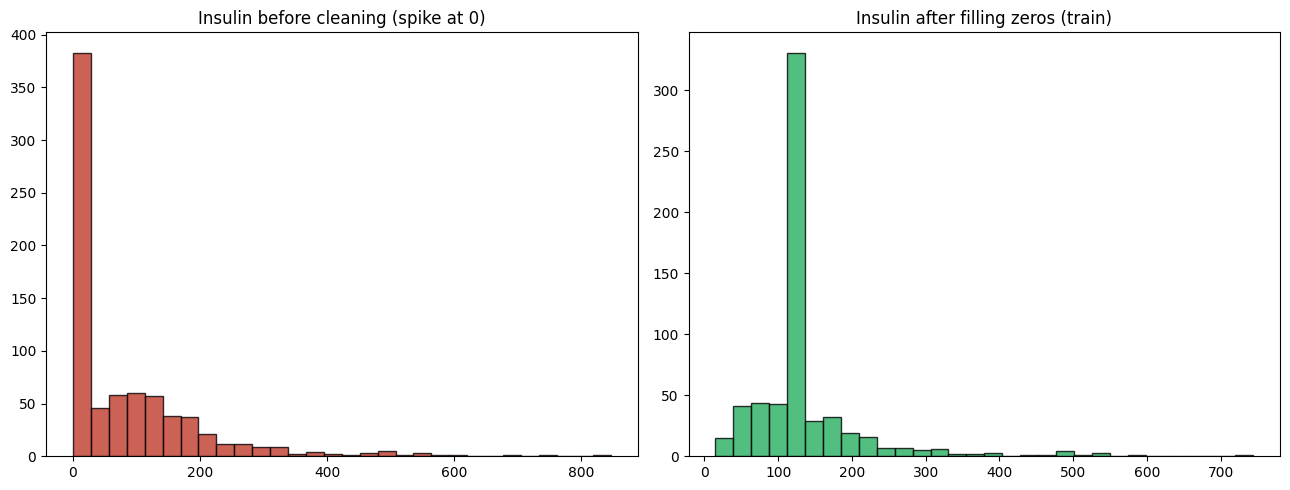

In [5]:
# اثر پر کردن صفرها روی Insulin که بیشترین صفر را داشت
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['Insulin'], bins=30, color='#c0392b', alpha=0.8, edgecolor='black')
axes[0].set_title('Insulin before cleaning (spike at 0)')
axes[1].hist(X_train['Insulin'], bins=30, color='#27ae60', alpha=0.8, edgecolor='black')
axes[1].set_title('Insulin after filling zeros (train)')
plt.tight_layout()
plt.savefig('../figures/before_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

## مرحلهٔ ۳: مقیاس‌بندی

ویژگی‌ها رو استاندارد می‌کنم (میانگین صفر، انحراف معیار یک).

این کار مخصوصاً برای SVM مهمه که به مقیاس حساسه. scaler فقط روی train فیت می‌شه و بعد
روی test اعمال می‌شه.

In [6]:
# استانداردسازی scaler فقط روی train فیت می‌شود
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('scaled training features (mean ~0, std ~1):')
for i, col in enumerate(feature_names):
    print(f'  {col:26s} mean={X_train_scaled[:, i].mean():+.2f}  std={X_train_scaled[:, i].std():.2f}')

scaled training features (mean ~0, std ~1):
  Pregnancies                mean=-0.00  std=1.00
  Glucose                    mean=-0.00  std=1.00
  BloodPressure              mean=+0.00  std=1.00
  SkinThickness              mean=-0.00  std=1.00
  Insulin                    mean=-0.00  std=1.00
  BMI                        mean=+0.00  std=1.00
  DiabetesPedigreeFunction   mean=-0.00  std=1.00
  Age                        mean=-0.00  std=1.00


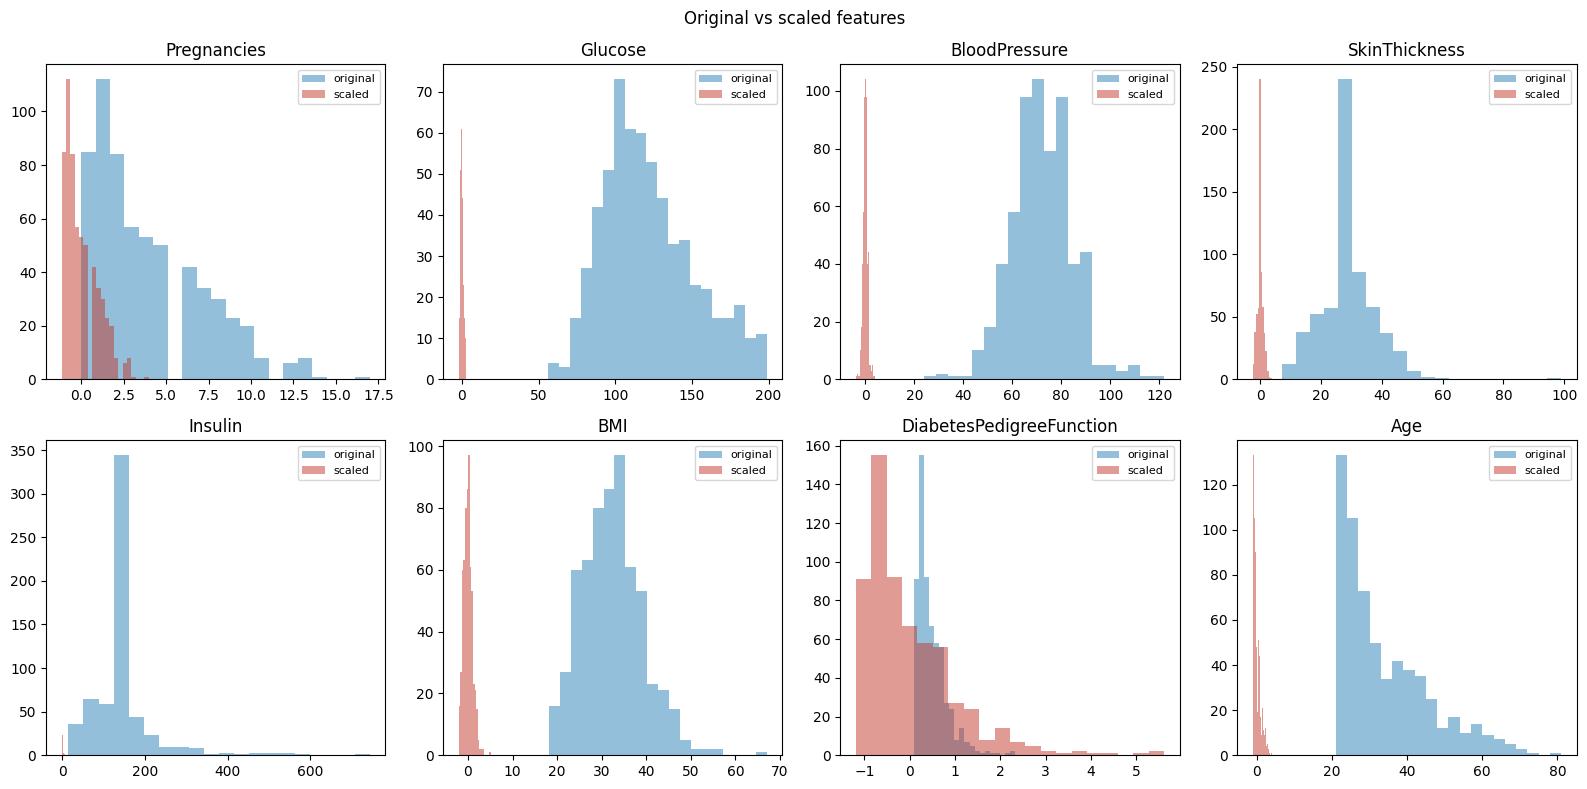

In [7]:
# مقایسه توزیع قبل و بعد از مقیاس‌بندی
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (ax, col) in enumerate(zip(axes.flat, feature_names)):
    ax.hist(X_train[col], bins=20, alpha=0.5, label='original', color='#2980b9')
    ax.hist(X_train_scaled[:, i], bins=20, alpha=0.5, label='scaled', color='#c0392b')
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle('Original vs scaled features')
plt.tight_layout()
plt.savefig('../figures/scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## ذخیره

همه‌چیزی که نوت‌بوک بعدی لازم داره رو ذخیره می‌کنم از جمله میانه‌ها و scaler که
بعدا بتونم روی یه بیمار جدید هم همین کارها رو بکنم

In [8]:
# ذخیره داده آماده‌شده برای نوت‌بوک بعدی
data = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train.values,
    'y_test': y_test.values,
    'scaler': scaler,
    'medians': medians,
    'feature_names': feature_names,
}

os.makedirs('../models', exist_ok=True)
joblib.dump(data, '../models/preprocessed_data.pkl')
print('saved -> ../models/preprocessed_data.pkl')

saved -> ../models/preprocessed_data.pkl


## جمع‌بندی

خلاصه کاری که کردم:

- تقسیم ۸۰ به ۲۰ به‌صورت طبقه‌ای
- پر کردن صفرها با میانهٔ داد آموزش
- مقیاس‌بندی با StandardScaler
- ذخیره داده برای مرحله بعد

اینکه تقسیم رو قبل از پر کردن و مقیاس‌بندی انجام دادم همون چیزیه که ارزیابی رو واقعی
نگه می‌داره